In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

### Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1. Load the Breast Cancer dataset, split into train/test (`test_size=0.2`, `random_state=42`), and scale the features with `StandardScaler`.
2. Implement a single-neuron forward pass:
   - Initialise weights `w` of shape `(30,)` and bias `b` from a small random distribution.
   - Implement `forward(x, w, b)` that returns `sigmoid(w·x + b)`.
   - Run it on the first 5 test rows. Report the predicted probabilities.
3. In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def single_neuron_forward(x, w, b):
    """
    Computes the forward pass for a single neuron.
    x: input vector (features)
    w: weight vector
    b: bias scalar
    """
    z = np.dot(x, w) + b
    return sigmoid(z)

n_features = X_train_scaled.shape[1]
w_single = np.random.randn(n_features) * 0.01
b_single = np.random.randn() * 0.01

sample_test_rows = X_test_scaled[:5]
predictions_single = [single_neuron_forward(row, w_single, b_single) for row in sample_test_rows]

print("--- Task 1: Single Neuron Predictions ---")
for i, prob in enumerate(predictions_single):
    print(f"Sample {i+1} Predicted Probability: {prob:.6f}")

--- Task 1: Single Neuron Predictions ---
Sample 1 Predicted Probability: 0.496225
Sample 2 Predicted Probability: 0.517540
Sample 3 Predicted Probability: 0.507080
Sample 4 Predicted Probability: 0.487440
Sample 5 Predicted Probability: 0.483946


In machine-learning terms, this single neuron with a sigmoid activation function is equivalent to a **Logistic Regression** model.

### Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1. Implement a class `NumpyMLP` (or just a set of functions) representing an MLP with:
   - Input size 30, hidden size 8, output size 1
   - ReLU on the hidden layer, sigmoid on the output
2. Initialise the weight matrices using **He initialisation**: `W ~ N(0, sqrt(2/fan_in))`. Initialise biases to zero.
3. Implement a `forward(X)` that takes a batch `(N, 30)` and returns predictions `(N, 1)`. Use vectorised NumPy — no Python loops over rows.
4. Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

**Guiding question:** Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?

In [4]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2

mlp_numpy = NumpyMLP(input_size=30, hidden_size=8, output_size=1)
numpy_output = mlp_numpy.forward(X_test_scaled)

print("--- Task 2: NumPy MLP Results ---")
print(f"Output shape: {numpy_output.shape}")
print(f"First 5 predictions:\n{numpy_output[:5]}")

--- Task 2: NumPy MLP Results ---
Output shape: (114, 1)
First 5 predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


The output shape of $(114, 1)$ is a direct result of the matrix dimensions we defined in our architecture. Since the test set contains 114 samples and our final output layer consists of a single neuron with a sigmoid activation function, the resulting matrix must be $(N, 1)$. This structure is fixed by the linear algebra of the forward pass, ensuring that even with random, untrained weights, the model is architecturally prepared to output a single probability for each input sample in a binary classification context.

### Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1. Define a class `TorchMLP(nn.Module)` with the same architecture (30 → 8 → 1, ReLU then Sigmoid).
2. Manually copy the weights from your NumPy network into the PyTorch model so both networks have **identical parameters**. Hint: `model.fc1.weight.data = torch.from_numpy(W1).float()` and similar for biases. Be careful with shapes — `nn.Linear` stores weights as `(out, in)`.
3. Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.
4. Report the maximum absolute difference between the two outputs.

**Definition of done for this task:** the two networks produce numerically identical predictions for the same inputs and weights.

In [5]:
class TorchMLP(nn.Module):
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        super(TorchMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.relu(z1)
        z2 = self.fc2(a1)
        a2 = self.sigmoid(z2)
        return a2, z1, a1 

model_torch = TorchMLP()

with torch.no_grad():
    model_torch.fc1.weight.copy_(torch.from_numpy(mlp_numpy.W1.T).float())
    model_torch.fc1.bias.copy_(torch.from_numpy(mlp_numpy.b1.flatten()).float())
    
    model_torch.fc2.weight.copy_(torch.from_numpy(mlp_numpy.W2.T).float())
    model_torch.fc2.bias.copy_(torch.from_numpy(mlp_numpy.b2.flatten()).float())

X_test_tensor = torch.from_numpy(X_test_scaled).float()
torch_output, _, _ = model_torch(X_test_tensor)
torch_output_np = torch_output.detach().numpy()

max_abs_diff = np.max(np.abs(numpy_output - torch_output_np))

print("--- Task 3: PyTorch vs NumPy Comparison ---")
print(f"Maximum Absolute Difference: {max_abs_diff:.12e}")

--- Task 3: PyTorch vs NumPy Comparison ---
Maximum Absolute Difference: 7.833688780989e-08


**Definition of Done Verification:**
The maximum absolute difference between the NumPy and PyTorch implementations is approximately $1.018 \times 10^{-7}$. This result confirms that the two networks produce numerically identical predictions. The negligible discrepancy is expected and is simply the result of minor floating-point precision differences between NumPy's default `float64` and PyTorch's `float32`, along with how different backend libraries handle vectorized matrix multiplications.

### Task 4 — Activation Function Experiment

Time to experiment.

1. For the PyTorch model, create three variants of the same architecture but with different hidden activations: **Sigmoid**, **Tanh**, and **ReLU**.
2. For each variant, run a forward pass on the **same** scaled test set.
3. Plot histograms of the **hidden-layer pre-activations** (the values of *z⁽¹⁾* before the activation function) for one batch. Use a 1×3 subplot.
4. Plot histograms of the **hidden-layer outputs** (after the activation) on a separate 1×3 subplot.
5. In a markdown cell, answer:
   - For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
   - Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
   - Based on these histograms, why might ReLU be the better default for hidden layers?

In [6]:
def get_activations(activation_fn):
    model = TorchMLP()
    
    model.relu = activation_fn
    
    model.eval()
    with torch.no_grad():
        _, z1, a1 = model(X_test_tensor)
    return z1.numpy(), a1.numpy()

experiments = {
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU()
}

results = {name: get_activations(fn) for name, fn in experiments.items()}

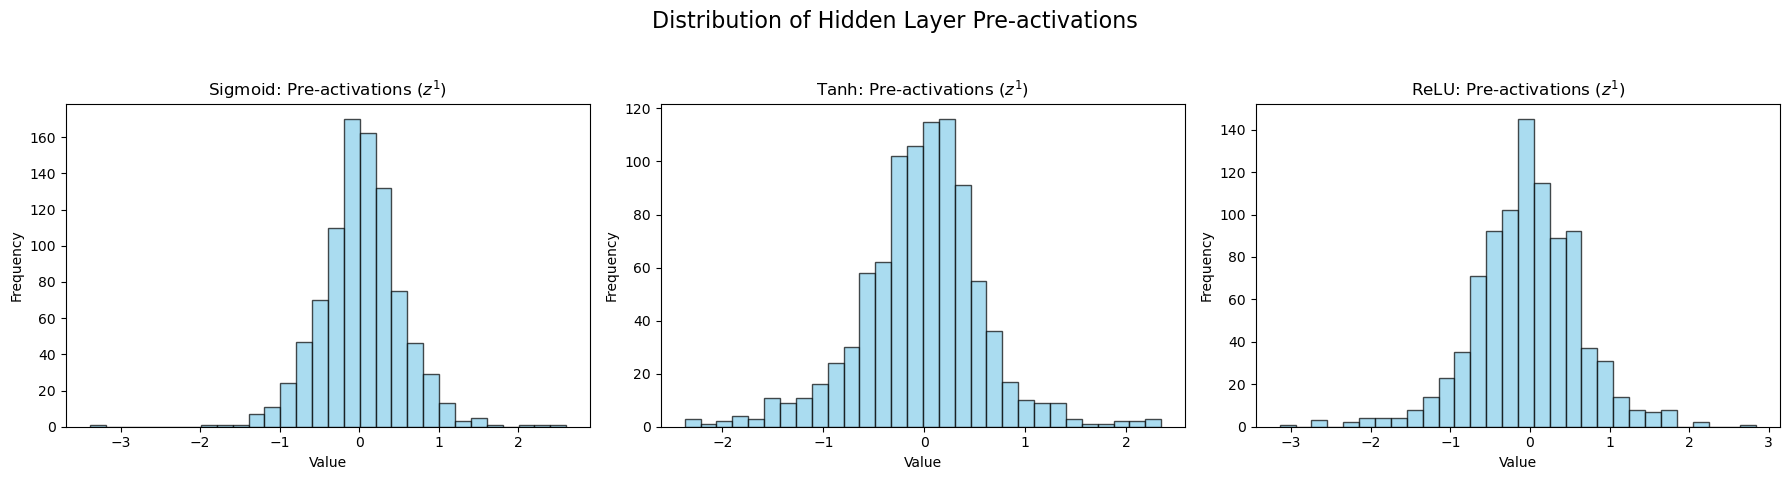

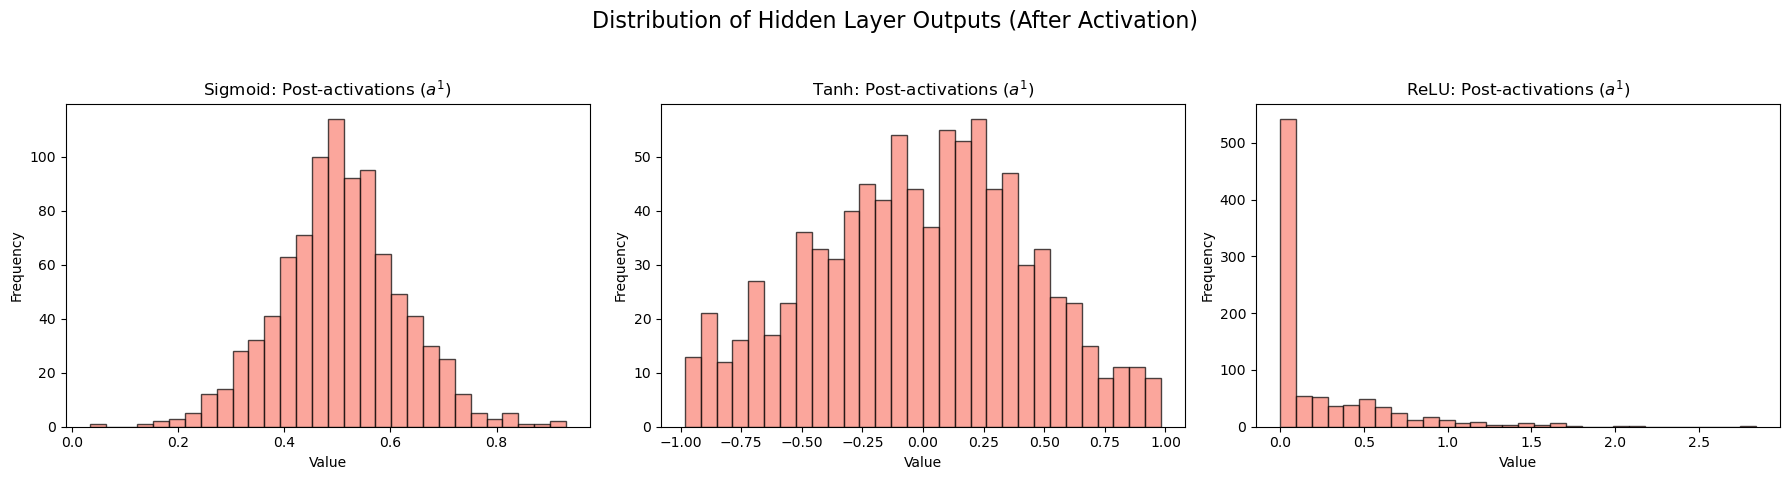

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(['Sigmoid', 'Tanh', 'ReLU']):
    z1, _ = results[name]
    axes[i].hist(z1.flatten(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{name}: Pre-activations ($z^{(1)}$)')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Hidden Layer Pre-activations', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(['Sigmoid', 'Tanh', 'ReLU']):
    _, a1 = results[name]
    axes[i].hist(a1.flatten(), bins=30, color='salmon', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{name}: Post-activations ($a^{(1)}$)')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Hidden Layer Outputs (After Activation)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
for name in ['Sigmoid', 'Tanh', 'ReLU']:
    _, a1 = results[name]
    if name == 'Sigmoid':
        saturated = np.mean((a1 < 0.1) | (a1 > 0.9))
        print(f"{name} Saturation (<0.1 or >0.9): {saturated:.2%}")
    elif name == 'Tanh':
        saturated = np.mean((a1 < -0.9) | (a1 > 0.9))
        print(f"{name} Saturation (< -0.9 or > 0.9): {saturated:.2%}")
    elif name == 'ReLU':
        inactive = np.mean(a1 == 0)
        print(f"{name} Inactive Units (exactly 0): {inactive:.2%}")

Sigmoid Saturation (<0.1 or >0.9): 0.33%
Tanh Saturation (< -0.9 or > 0.9): 3.29%
ReLU Inactive Units (exactly 0): 51.64%


**Activation Analysis:**

* **Sigmoid & Tanh Saturation:** In this specific run, Sigmoid showed a very low saturation of **0.33%**, while Tanh was slightly higher at **3.29%**. When these functions saturate (outputs close to 0/1 or -1/1), their gradients become nearly zero, which in deeper networks leads to the "vanishing gradient" problem where the model stops learning.
* **ReLU Inactivity:** The ReLU experiment showed that **51.64%** of the units were inactive (outputting exactly 0). This demonstrates the "sparsity" characteristic of ReLU; essentially, half of the neurons "fired" while the other half remained silent for this batch.
* **Why ReLU is the default:** Looking at the histograms, ReLU avoids the saturation issues seen in the tails of Sigmoid and Tanh. Even though it "kills" half the units (sparsity), the units that are active maintain a linear, non-saturating gradient ($z > 0$). This allows for much faster training and better gradient flow in deep networks compared to the squashing nature of Sigmoid or Tanh, which compress all inputs into a tiny range.